# Test case LVV-T1074-b: Sky Brightness precision

> **The maximum error in the precision of the sky brightness determination shall be less than SBPerc = 1 percent.**

This test verifies the following requirements:

- LSR-REQ-0093-V-07: Sky brightness determination (https://rubinobs.atlassian.net/browse/LVV-9800)
- OSS-REQ-0387-V-05: Sky Brightness precision (https://rubinobs.atlassian.net/browse/LVV-13366)


#### Discussion

From LVV-9800:

> On real data: run DM stack on images in a variety of conditions, which determines a polynomial fit for the sky, compare the actual sky measurement at points not on the polynomial grid and check that they agree to 1 percent.

Our interpretation of this suggestion in this notebook is to compare the flux values in "empty" regions of the sky using sky objects against the fitted background polynomial model produced by the LSST Science Pipelines.

This test notebook can be run using data products produced during regular reprocessing campaigns executed by the Data Management pipelines team.

Initial testing of this notebook was performed using data in the following collections:

- `LSSTCam/runs/DRP/20250420_20250429/w_2025_18/DM-50628`


In [1]:
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
from lsst.afw.geom import SpanSet
from lsst.daf.butler import Butler
from lsst.utils.packages import getEnvironmentPackages
from tqdm import tqdm, trange


def print_session_info():
    # Time info
    print(f"# Session Info on {time.strftime('%Y-%m-%d at %H:%M:%S %Z', time.localtime(time.time()))}\n")

    # Python info
    print(f"## Python Interpreter\n\nVersion: {sys.version}  \nExecutable: {sys.executable}\n")

    # LSST info
    packages = getEnvironmentPackages(True)
    dev_packages = {"lsst_distrib": packages["lsst_distrib"]}
    dev_packages.update({k: v.split("@")[0] for k, v in packages.items() if "LOCAL" in v})
    print("## Science Pipelines\n\n" + "\n".join(f"{k:<20} {v}" for k, v in dev_packages.items()))


print_session_info()

# Session Info on 2025-10-07 at 09:47:33 PDT

## Python Interpreter

Version: 3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:45:31) [GCC 13.3.0]  
Executable: /sdf/group/rubin/sw/conda/envs/lsst-scipipe-11.0.0/bin/python

## Science Pipelines

lsst_distrib         gdfb3db0272+fdbdb654ae (w_2025_39 w_latest)


In [2]:
# Choose a data collection
instrument = "LSSTCam"
collection = "LSSTCam/runs/DRP/20250420_20250429/w_2025_18/DM-50628"

In [3]:
# Instantiate the Butler
repo = "/repo/main"
butler = Butler.from_config(repo, collections=collection)

In [4]:
# Define a visit list
refsImages = butler.query_datasets("visit_image", collections=collection)
refsCatalogs = butler.query_datasets("recalibrated_star", collections=collection)
visitsImages = [x.dataId["visit"] for x in refsImages if (x.dataId["band"] == "g")]  # g-band only
visits = [x.dataId["visit"] for x in refsCatalogs if (x.dataId["visit"] in visitsImages)]  # With both images and catalogues

In [5]:
# Build a list of available detectors
dataset = butler.query_datasets(dataset_type="visit_image",
                                collections=collection,
                                where="visit=%d" % (visits[0]),  # Assumes all visits have the same available detectors
                                find_first=False)
detectors = [i.dataId["detector"] for i in dataset]
d_idx = np.random.choice(len(detectors), size=9, replace=False)
detectors = [detectors[i] for i in d_idx]
visits = visits[: 10]  # limit to a sub-sample of visits

In [6]:
# Set the mask planes to ignore, following defaults in `background.py` used by `skyCorr`
badMaskPlanes = ["SAT", "BAD", "EDGE", "DETECTED", "DETECTED_NEGATIVE", "NO_DATA"]

In [7]:
print(f"{repo = }\n{collection = }\n{len(visits) = }")

repo = '/repo/main'
collection = 'LSSTCam/runs/DRP/20250420_20250429/w_2025_18/DM-50628'
len(visits) = 10


#### Functions

The cells below define functions that retrieve image, background, and metadata (`retrieveImageAndBackground`) and retrieve sky sources (`retrieveSkySources`).


In [8]:
def retrieveImageAndBackground(dataId, collection):
    """Retrieve the sky-subtracted calibrated exposure and associated metadata.

    Parameters
    ----------
    dataId : `dict`
        Dictionary containing "visit", "detector", and "instrument" values for
        image retrieval
    collection : `str`
        Name of the collection in which the desired images are stored

    Returns
    -------
    visitImage : `ImageF`
        visitImage with the `visit_image_background` subtracted from it, converted to nJy
    background : `ImageF`
        visit_image_background image, converted to nJy
    """
    # Retrieve the image, metadata, and calibration
    visitImage = butler.get("visit_image", dataId=dataId, collections=collection)
    background = butler.get("visit_image_background", dataId=dataId, collections=collection)
    
    photoZp = visitImage.getPhotoCalib().instFluxToNanojansky(1)

    backgroundImage = background.getImage().array
    visitImage.image.array *= photoZp
    backgroundImage *= photoZp

    return visitImage, backgroundImage

In [9]:
def retrieveSkySources(dataId, collection, aper=9):
    """Retrieve sky source aperture fluxes for a given detector / visit.

    Parameters
    ----------
    dataId : `dict`
        Dictionary containing "visit", "detector", and "instrument" values for
        image retrieval
    collection : `str`
        Name of the collection in which the desired images are stored
    aper : `int`
        Choice of sky source aperture radius. Valid are 3,6,9,12,25,35,70.
        The 9 pixel aperture is recommended as sky sources are defined as being
        >8px from the nearest detection.

    Returns
    -------
    x : `numpy.ndarray`
        X pixel coordinates of sky sources.
    y : `numpy.ndarray`
        Y pixel coordinates of sky sources.
    skySourceFlux : `numpy.ndarray`
        Mean fluxes of sky sources within circular aperture of radius aper.
        Units are nJy.
    """
    # Retrieve table
    srcTab = butler.get("recalibrated_star_detector", dataId=dataId, collections=collection)
    isSky = srcTab["sky_source"] > 0  # Pick only sky sources
    skySources = srcTab[isSky]["ap%02dFlux" % (aper)]  # Units are nJy already
    nPix = np.pi * aper**2  # Number of pixels per aperture

    return np.array(srcTab[isSky]["x"]), np.array(srcTab[isSky]["y"]), np.array(skySources / nPix)

The cells below define functions for measuring the mean flux within a single sky aperture on a new image (`getMeanImageValueInAperInd`), for deriving mean fluxes within all sky apertures from a `calexp` image and its associated background (`getMeanImageAndBackgroundInAper`), for computing the metric **SBPerc** defined as the ratios between the total (image and background) sky aperture fluxes to the background aperture fluxes (`computeSBRatio`), and for deriving **SBPerc** for a specific visit ID (`processVisit`).

In [10]:
def getMeanImageValueInAperInd(image, x, y, aper):
    """Compute the mean image values at a given pixel location within a
    circular aperture.

    Parameters
    ----------
    image : `array-like`
        Image from which to extract the mean value (e.g., a calexp or a
        background image)
    x : `int`
        X pixel coordinate (row) of the center of the aperture
    y : `int`
        Y pixel coordinate (column) of the center of the aperture
    aper : `int`
        Radius of the circular aperture in pixels

    Returns
    -------
    meanFluxInAper : `float`
        Mean flux within the aperture, computed using the actual number of
        pixels inside the aperture
    """
    # Ensure x and y are integers and background is a numpy array
    x, y = int(x), int(y)
    if hasattr(image, "image"):
        background = image.image.array
    elif hasattr(image, "getImage"):
        background = image.getImage().array
    elif isinstance(image, np.ndarray):
        background = image
    else:
        raise ValueError(f"Input image is not a valid type: {type(image)}")
    rows, cols = background.shape

    # Create grid arrays for the entire image using ogrid (memory efficient)
    X, Y = np.ogrid[: rows, : cols]

    # Create mask for points within the circle (distance from (x, y) <= aper)
    mask = ((X - x) ** 2 + (Y - y) ** 2) <= aper**2

    # Compute the mean using the actual number of pixels within the mask
    nPix = np.sum(mask)

    # 9 pixel aperture has 253 pixels if unmasked, so we scale area accordingly
    nAperPixels = int(np.sum(SpanSet.fromShape(int(aper)).asArray()))  # 253
    area = nPix / nAperPixels * np.pi * aper**2

    # There are some sky sources that are out of bounds, return 0 in this case
    if nPix == 0:
        meanFluxInAper = 0
    else:
        meanFluxInAper = background[mask].sum() / area

    return meanFluxInAper

In [11]:
def getMeanImageAndBackgroundInAper(calexp, backgroundImage, xSeries, ySeries, aper):
    """Compute the mean background at a given pixel location within a circular
    aperture for a location list.
    
    visitImage : `ImageF`
        visitImage with the `visit_image_background` subtracted from it
    visit_image_background : `ImageF`
        visit_image_background object
    xSeries : `numpy.ndarray`
        X pixel coordinates of sky sources.
    ySeries : `numpy.ndarray`
        Y pixel coordinates of sky sources.
    aper : `int`
        Choice of sky source aperture radius. Valid are 3,6,9,12,25,35,70.
        The 9 pixel aperture is recommended as sky sources are defined as being
        >8px from the nearest detection.

    Returns
    -------
    meanImageFluxInAperList : `numpy.ndarray`
        Mean fluxes from `calexp` within input sky source apertures
    meanBackgroundFluxInAperList : `numpy.ndarray`
        Mean fluxes from `backgroundImage` within input sky source apertures
    """
    meanBackgroundFluxInAperList = []
    meanImageFluxInAperList = []

    for x, y in zip(xSeries, ySeries):
        meanImageFluxInAper = getMeanImageValueInAperInd(calexp, x, y, aper)
        meanBackgroundFluxInAper = getMeanImageValueInAperInd(backgroundImage, x, y, aper)
        meanBackgroundFluxInAperList.append(meanBackgroundFluxInAper)
        meanImageFluxInAperList.append(meanImageFluxInAper)
    return np.array(meanImageFluxInAperList), np.array(meanBackgroundFluxInAperList)

In [12]:
def computeSBRatio(dataId, aper=9):
    """Compute the signal-to-background ratio for a given detector / visit.

    Parameters
    ----------
    dataId : `dict`
        Dictionary containing "visit", "detector", and "instrument" values for
        image retrieval
    aper : `int`
        Choice of sky source aperture radius. Valid are 3,6,9,12,25,35,70.
        The 9 pixel aperture is recommended as sky sources are defined as being
        >8px from the nearest detection.

    Returns
    -------
    visit_image : `ImageF`
        visit_image with the `visit_image_background` subtracted from it, converted to nJy
    background : `ImageF`
        visit_image_background image, converted to nJy
    meanImageFluxInAper : `numpy.ndarray`
        Mean fluxes from `calexp` within input sky source apertures
    meanBackgroundFluxInAper : `numpy.ndarray`
        Mean fluxes from `backgroundImage` within input sky source apertures
    xSky : `numpy.ndarray`
        X pixel coordinates of sky sources.
    ySky : `numpy.ndarray`
        Y pixel coordinates of sky sources.
    meanFluxInSky : `numpy.ndarray`
        Mean fluxes of sky sources within circular aperture of radius aper.
        Units are nJy.
    SBRatio : `numpy.ndarray`
        Total image + background fluxes in sky apertures / background fluxes in apertures
    """
    # Comment AEW: should `collection` be the global notebook one, or a parameter?
    calexp, background = retrieveImageAndBackground(dataId, collection)
    xSky, ySky, meanFluxInSky = retrieveSkySources(dataId, collection, aper=aper)
    meanImageFluxInAper, meanBackgroundFluxInAper = getMeanImageAndBackgroundInAper(
        calexp, background, xSky, ySky, aper=9
    )

    if len(meanFluxInSky) == 0:
        return None

    # Compute SBPrec ratio
    # Mask out all background aperture values that are zero
    zeroMask = meanBackgroundFluxInAper == 0
    # The sky source flux is background subtracted, so we need to add the background back in
    SBRatio = (meanBackgroundFluxInAper[~zeroMask] + meanFluxInSky[~zeroMask]) / meanBackgroundFluxInAper[
        ~zeroMask
    ]

    return (
        calexp,
        background,
        meanImageFluxInAper,
        meanBackgroundFluxInAper,
        xSky,
        ySky,
        meanFluxInSky,
        SBRatio,
    )

In [13]:
def processVisit(visit):
    """Process a single visit across all detectors.

    Parameters
    ----------
    visit : `int`
        ID of the visit to be processed

    Returns
    -------
    results : `dict`
        Dictionary containing all outputs from computeSBRatio()
    """

    results = {
        "visit": visit,
        "SBRatio": [],
        "SBPerc": [],
        "calexp": [],
        "backgroundImage": [],
        "xSky": [],
        "ySky": [],
        "meanBackgroundInAper": [],
        "meanImageFluxInAper": [],
        "meanFluxInSky": [],
    }

    for det in detectors:
        dataId = {"visit": visit, "detector": det, "instrument": "LSSTCam"}

        result = computeSBRatio(dataId)
        if result is not None:
            (
                calexp,
                backgroundImage,
                meanImageFluxInAper,
                meanBackgroundInAper,
                xSky,
                ySky,
                meanFluxInSky,
                SBRatio,
            ) = result

            results["calexp"].append(calexp)
            results["backgroundImage"].append(backgroundImage)
            results["xSky"].append(xSky)
            results["ySky"].append(ySky)
            results["meanImageFluxInAper"].append(meanImageFluxInAper)
            results["meanBackgroundInAper"].append(meanBackgroundInAper)
            results["meanFluxInSky"].append(meanFluxInSky)
            results["SBRatio"].append(SBRatio)

    return results

Calculate the `SBRatio` for all visits.

In [14]:
resultList = []
for visit in tqdm(visits):
    resultList.append(processVisit(visit))

  0%|                                                     | 0/10 [00:00<?, ?it/s]

100%|████████████████████████████████████████████| 10/10 [14:50<00:00, 89.07s/it]


In [22]:
print(f"Number of visits processed: {len(resultList)}")
print(f"Number of detectors per visit: {len(detectors)}")

Number of visits processed: 10
Number of detectors per visit: 9


### Plots

Create histograms of the `SBRatio` parameter, as well as the minimum and maximum `SBRatio` values for each detector.

Total number of sky sources analyzed: 8864


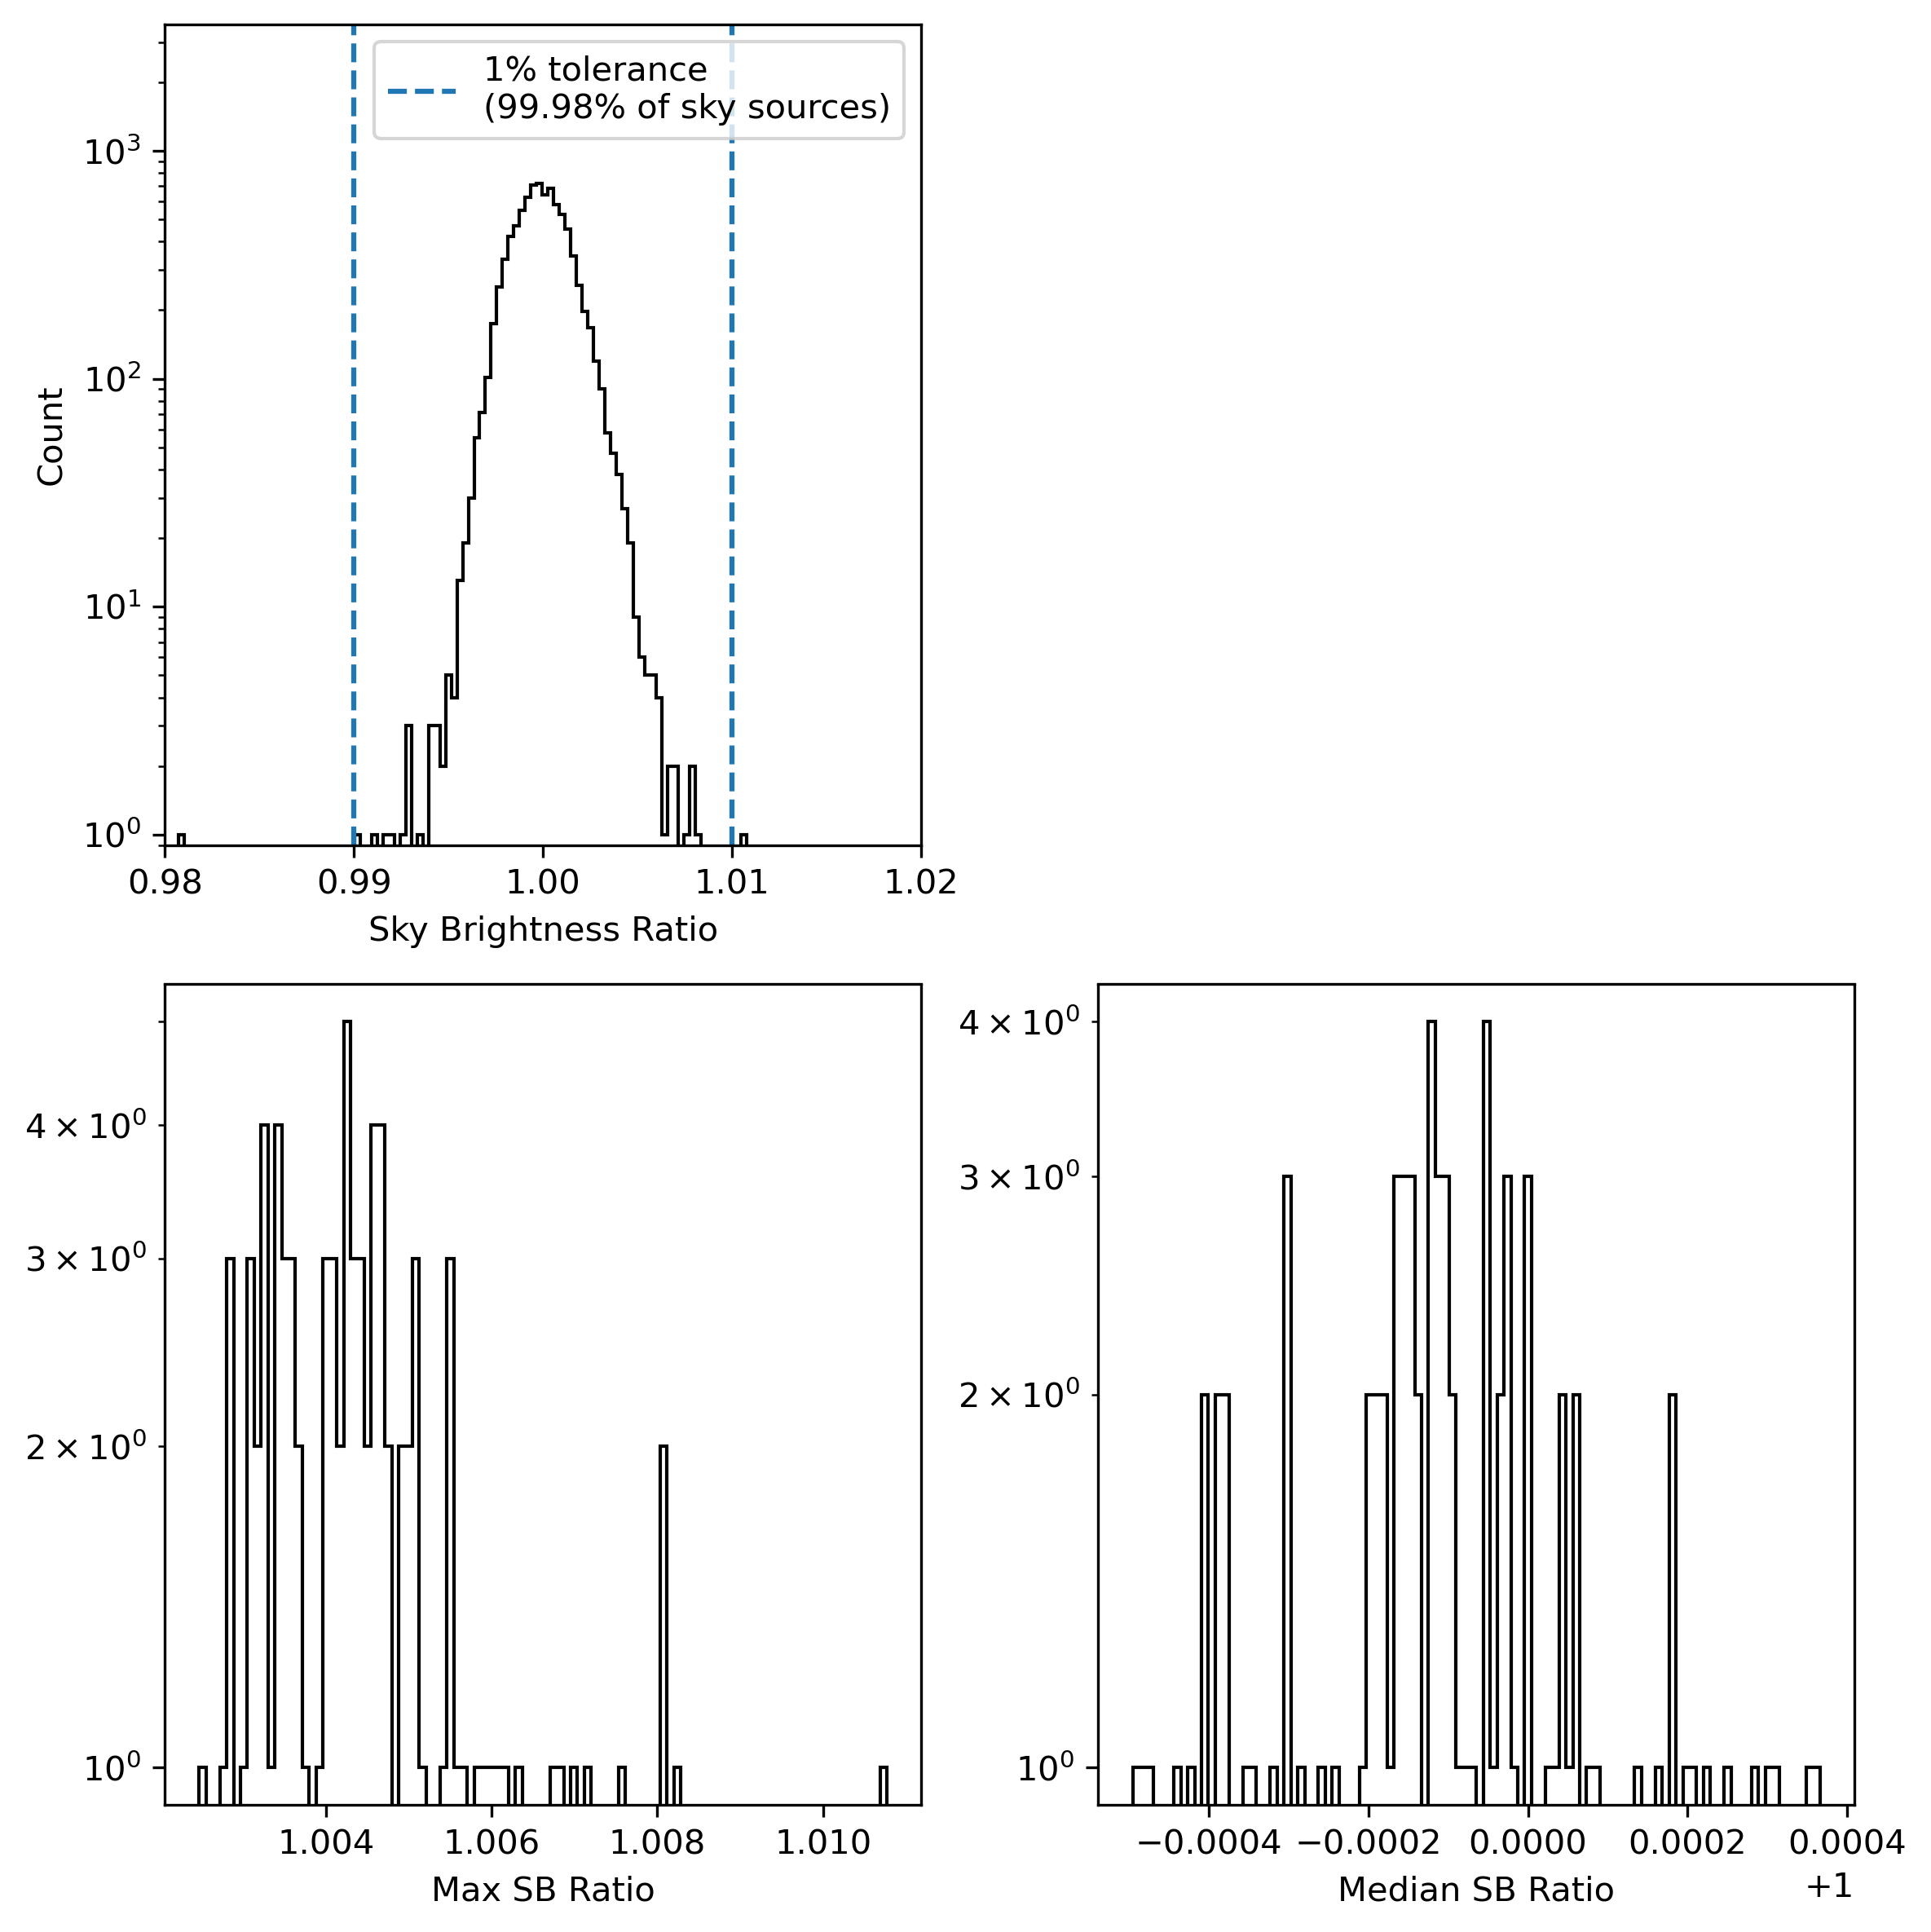

In [21]:
def plotSBRatio(resultList):
    """Plot the SBRatios visit.
    
    Parameters
    ----------
    resultList : `list`
        List of results dictionaries output by processVisit() for all visits
    """
    fig, axes = plt.subplots(2, 2, figsize=(8, 8), dpi=300)
    axes = axes.flatten()
    allSBRatio = np.concatenate([np.concatenate(res["SBRatio"]) for res in resultList])
    print(f"Total number of sky sources analyzed: {len(allSBRatio)}")
    frac_within_1pc = np.sum((allSBRatio >= 0.99) & (allSBRatio <= 1.01)) / len(allSBRatio)
    maxSBRatio = np.array([np.max(res["SBRatio"][det]) for res in resultList for det in range(9)])
    medianSBRatio = np.array([np.median(res["SBRatio"][det]) for res in resultList for det in range(9)])

    counts, bins, _ = axes[0].hist(allSBRatio, bins=100, histtype="step", color="k", log=True)
    axes[0].set_xlabel("Sky Brightness Ratio")
    axes[0].set_ylabel("Count")
    axes[0].axvline(1.01, linestyle="--")
    axes[0].axvline(0.99, linestyle="--", label=f"1% tolerance\n({frac_within_1pc*100:.2f}% of sky sources)")
    axes[0].legend()
    max_count = np.max(counts)
    axes[0].set_ylim(0.9, max_count * 5)
    # axes[0].set_xlim(np.percentile(allSBRatio, 0.01), np.percentile(allSBRatio, 99.9))
    axes[0].set_xlim(0.98, 1.02)

    axes[1].axis("off")

    axes[2].hist(maxSBRatio, bins=100, histtype="step", color="k", log=True)
    axes[2].set_xlabel("Max SB Ratio")

    axes[3].hist(medianSBRatio, bins=100, histtype="step", color="k", log=True)
    axes[3].set_xlabel("Median SB Ratio")

    plt.tight_layout()
    plt.show()


plotSBRatio(resultList)

Create scatterplots showing the `SBRatio` values as functions of the mean image fluxes within each sky aperture, the mean background fluxes within each sky aperture, and the x and y positions within each image.

High SB Ratio: 0.0


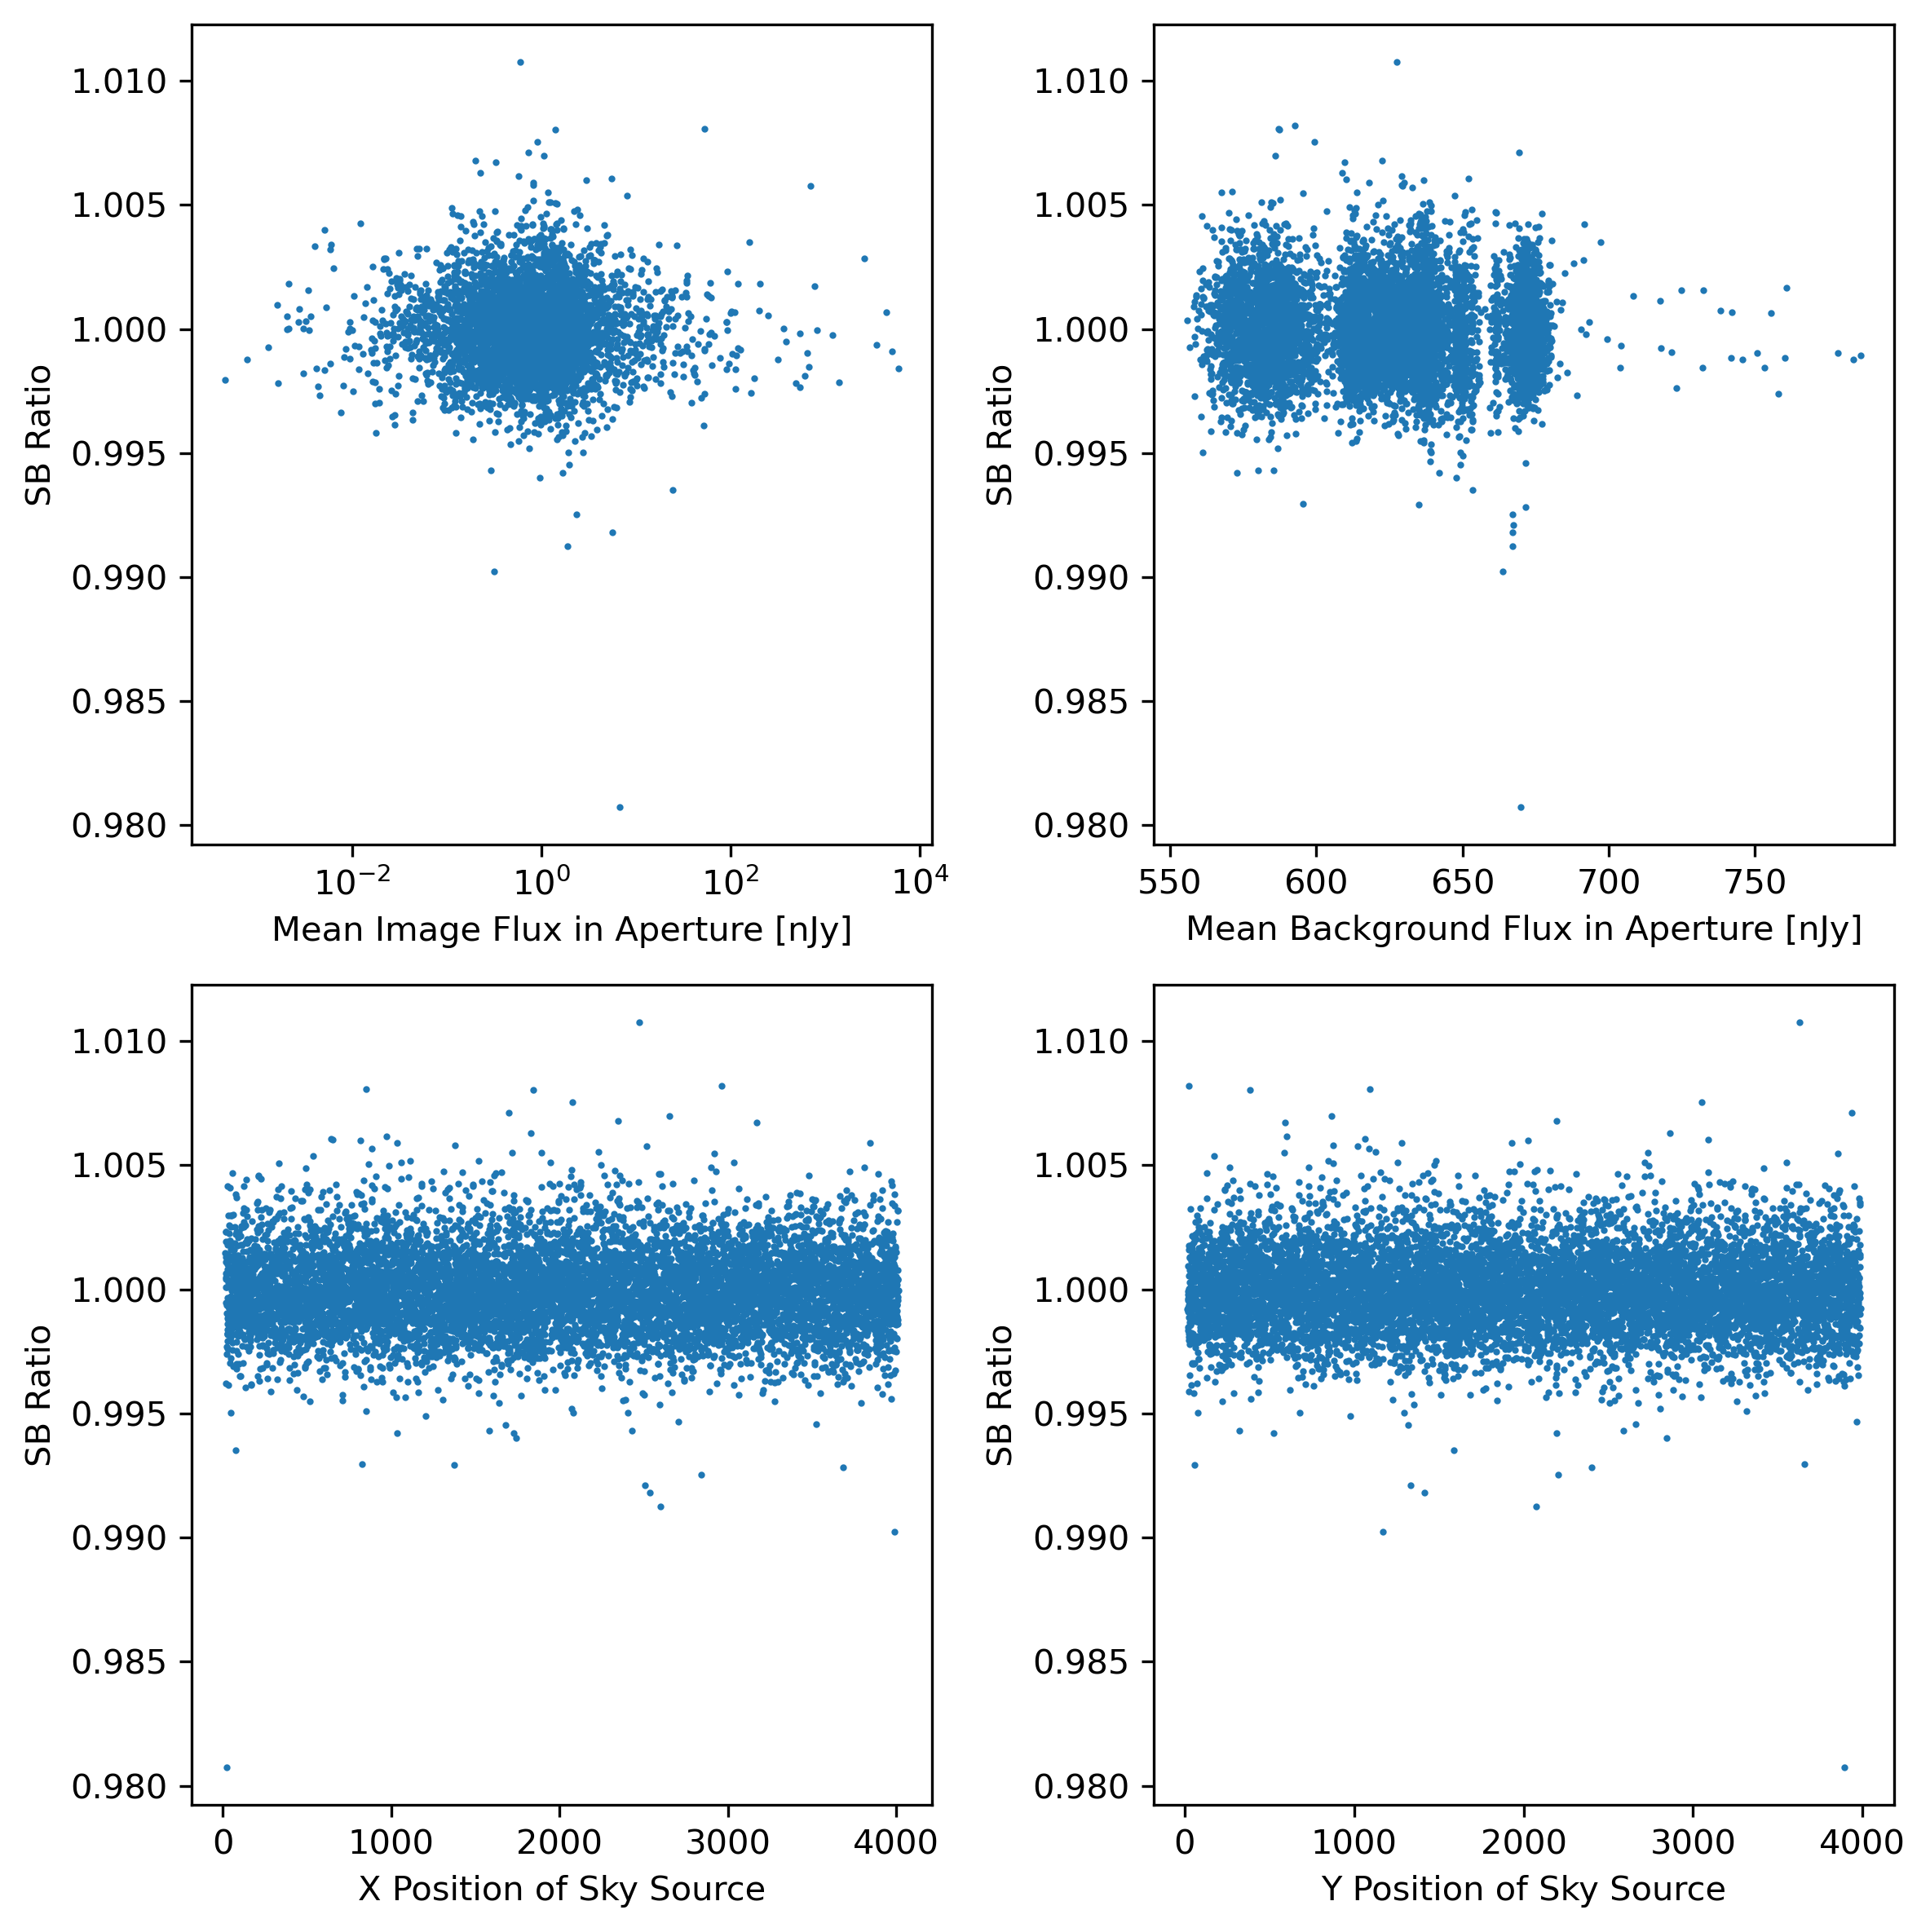

In [19]:
def plotCorrelation(resultList):
    """Plot the correlation between the image flux and SB ratio

    Parameters
    ----------
    resultList : `list`
        List of results dictionaries output by processVisit() for all visits
    """
    fig, axes = plt.subplots(2, 2, figsize=(8, 8), dpi=300)
    allMeanImageFluxInAper = np.concatenate(
        [np.concatenate(res["meanImageFluxInAper"]) for res in resultList]
    )
    allMeanBackgroundInAper = np.concatenate(
        [np.concatenate(res["meanBackgroundInAper"]) for res in resultList]
    )
    allxSky = np.concatenate([np.concatenate(res["xSky"]) for res in resultList])
    allySky = np.concatenate([np.concatenate(res["ySky"]) for res in resultList])

    zeroMask = allMeanBackgroundInAper == 0
    allMeanImageFluxInAper = allMeanImageFluxInAper[~zeroMask]
    allMeanBackgroundInApe = allMeanBackgroundInAper[~zeroMask]

    allxSky = allxSky[~zeroMask]
    allySky = allySky[~zeroMask]
    allSBRatio = np.concatenate([np.concatenate(res["SBRatio"]) for res in resultList])

    assert len(allMeanImageFluxInAper) == len(
        allSBRatio
    ), f"Length mismatch: {len(allMeanImageFluxInAper)} vs {len(allSBRatio)}"

    axes[0][0].scatter(allMeanImageFluxInAper, allSBRatio, s=1)
    axes[0][0].set_xlabel("Mean Image Flux in Aperture [nJy]")
    axes[0][0].set_ylabel("SB Ratio")
    axes[0][0].set_xscale("log")

    axes[0][1].scatter(allMeanBackgroundInApe, allSBRatio, s=1)
    axes[0][1].set_xlabel("Mean Background Flux in Aperture [nJy]")
    axes[0][1].set_ylabel("SB Ratio")

    axes[1][0].scatter(allxSky, allSBRatio, s=1)
    axes[1][0].set_xlabel("X Position of Sky Source")
    axes[1][0].set_ylabel("SB Ratio")
    axes[1][1].scatter(allySky, allSBRatio, s=1)
    axes[1][1].set_xlabel("Y Position of Sky Source")
    axes[1][1].set_ylabel("SB Ratio")

    highSBRatio = allSBRatio > 1.5
    print(f"High SB Ratio: {np.sum(highSBRatio)/len(allSBRatio)}")

    plt.tight_layout()
    plt.show()


plotCorrelation(resultList)

#### Conclusion

To be deemed a success, the requirement for LSR-REQ-0093-V-07 and OSS-REQ-0387-V-05 states that the sky brightness determination shall have a precision of 1 percent.
In this notebook, we have extracted the flux at positions on the sky that are not associated with any detected objects and compared these values to the background model produced by the LSST Science Pipelines.

We find that the maximum error in the precision of the sky brightness determination is less than 1 percent in ~99% of samples taken on real LSSTCam data.
As such, **we conclude that the requirement has been met**.
